# Predictive Maintenance of Hard Drives Using SMART Attributes
### Failure Prediction (N-day horizon) + Remaining Useful Life Regression
### A Deep Neural Network Approach with PyTorch

This Project predicts, for each drive-day reading in the **Backblaze Hard Drive
Dataset**, whether the drive is going to fail within the next **N days** (a binary
classification problem), and additionally estimates **how many days** remain until
failure for drives that are already degrading (a regression problem).


In [1]:
%pip install -q xgboost


Note: you may need to restart the kernel to use updated packages.


## 1. Configuration & Data Loading



In [2]:
import os
import zipfile
import urllib.request
import numpy as np
import pandas as pd
from tqdm import tqdm

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
import torch
torch.manual_seed(RANDOM_STATE)

# ---- Toggle this: True = fast pipeline check on a data sample, False = full run ----
QUICK_TEST = False
QUICK_SAMPLE_N_DRIVES = 3000   # number of drives kept when QUICK_TEST is True

# ---- Add more quarters here for more failure events (each is ~1-2 GB zipped) ----
QUARTER_URLS = [
    "https://f001.backblazeb2.com/file/Backblaze-Hard-Drive-Data/data_Q1_2023.zip",
    "https://f001.backblazeb2.com/file/Backblaze-Hard-Drive-Data/data_Q2_2023.zip",
]

# ---- Project layout: bulk data in data/, weights in models/, tables in results/ ----
DATA_DIR = "data"         # downloaded quarters + their extracted CSVs
MODELS_DIR = "models"     # weights (.pth/.json) + their preprocessing configs
RESULTS_DIR = "results"   # metric and analysis tables
for _d in (DATA_DIR, MODELS_DIR, RESULTS_DIR):
    os.makedirs(_d, exist_ok=True)

FAILURE_HORIZON_DAYS = 10   # classification target: "will this drive fail within N days?"
RUL_HORIZON_DAYS = 60       # regression target window: predict RUL only within this many days of failure
DELTA_WINDOW_DAYS = 7        # trailing window used for rate-of-change features
MODEL_PREFIX_FILTER = "ST"   # keep Seagate drives only, for a consistent, comparable model family

# Only these columns are used downstream (identifiers + the 9 SMART attributes that
# become BASE_RAW_FEATURES in Section 3). A daily CSV carries ~180 columns, so loading
# all of them would put ~20M Seagate drive-days in ~32 GB of RAM -- and Sections 4-5
# each take a full copy. Restricting the read keeps the same rows in ~5 GB.
# It also pins the schema: Q1 2023 files have 179 columns and Q2 2023 files have 186,
# so an unrestricted concat would silently produce NaN-filled columns for the
# attributes Backblaze only started reporting mid-year.
ID_COLUMNS = ["date", "serial_number", "model", "failure"]
SMART_RAW_COLUMNS = [
    "smart_5_raw",    # Reallocated Sectors Count
    "smart_9_raw",    # Power-On Hours
    "smart_187_raw",  # Reported Uncorrectable Errors
    "smart_188_raw",  # Command Timeout
    "smart_194_raw",  # Temperature (Celsius)
    "smart_197_raw",  # Current Pending Sector Count
    "smart_198_raw",  # Offline Uncorrectable Sector Count
    "smart_199_raw",  # UDMA CRC Error Count
    "smart_241_raw",  # Total LBAs Written
]
USE_COLUMNS = ID_COLUMNS + SMART_RAW_COLUMNS


def find_daily_csvs(extract_folder):
    '''All daily CSV paths under an extracted quarter.

    Skips the `__MACOSX/._*.csv` AppleDouble stubs the archives carry: they end in
    ".csv" but are 268-byte resource forks, and read_csv would reject them once
    `usecols` is in play.
    '''
    return sorted(
        os.path.join(root, f)
        for root, _, files in os.walk(extract_folder)
        for f in files
        if f.endswith(".csv") and not f.startswith("._")
    )


def load_backblaze(quarter_urls, model_prefix_filter=MODEL_PREFIX_FILTER):
    '''Download and concatenate one or more Backblaze quarterly SMART datasets.

    Returns a DataFrame with columns: id, time, failure, model, and the SMART raw
    attributes listed in SMART_RAW_COLUMNS.
    '''
    all_chunks = []
    for quarter_url in quarter_urls:
        zip_filename = os.path.join(DATA_DIR, os.path.basename(quarter_url))
        extract_folder = zip_filename.replace(".zip", "")

        if not os.path.exists(zip_filename):
            print(f"Downloading {quarter_url} ...")
            urllib.request.urlretrieve(quarter_url, zip_filename)
            print("Download complete.")
        else:
            print(f"Zip already present: {zip_filename}")

        if not os.path.exists(extract_folder):
            print(f"Extracting to {extract_folder}/ ...")
            with zipfile.ZipFile(zip_filename, "r") as z:
                z.extractall(extract_folder)
        else:
            print(f"Already extracted: {extract_folder}/")

        csv_files = find_daily_csvs(extract_folder)
        print(f"  Found {len(csv_files)} daily CSV files in {extract_folder}/")

        for fp in tqdm(csv_files, desc=f"Loading {extract_folder}"):
            df_chunk = pd.read_csv(fp, encoding="latin1", low_memory=False, usecols=USE_COLUMNS)
            if "date" not in df_chunk.columns or "model" not in df_chunk.columns:
                continue
            df_chunk["date"] = pd.to_datetime(df_chunk["date"])
            if model_prefix_filter:
                df_chunk = df_chunk[df_chunk["model"].astype(str).str.startswith(model_prefix_filter)]
            all_chunks.append(df_chunk)

    df = pd.concat(all_chunks, ignore_index=True)
    df = df.rename(columns={"serial_number": "id", "date": "time"})
    df = df.sort_values(["id", "time"]).reset_index(drop=True)
    return df


print(f"QUICK_TEST = {QUICK_TEST}")
print(f"Quarters to load: {len(QUARTER_URLS)}")
print(f"Failure horizon (classification target): {FAILURE_HORIZON_DAYS} days")
print(f"RUL horizon (regression window): {RUL_HORIZON_DAYS} days")

QUICK_TEST = False
Quarters to load: 2
Failure horizon (classification target): 10 days
RUL horizon (regression window): 60 days


## 2. Data Understanding

Load the raw dataset and inspect its shape, schema, date range.

In [3]:
raw_df = load_backblaze(QUARTER_URLS)

if QUICK_TEST:
    failing_ids = raw_df.loc[raw_df["failure"] == 1, "id"].unique()
    healthy_ids = raw_df.loc[~raw_df["id"].isin(failing_ids), "id"].unique()
    # Keep ALL failing drives (they're rare and precious) + a random sample of healthy ones
    n_healthy_keep = max(QUICK_SAMPLE_N_DRIVES - len(failing_ids), 100)
    rng = np.random.RandomState(RANDOM_STATE)
    healthy_sample = rng.choice(healthy_ids, size=min(n_healthy_keep, len(healthy_ids)), replace=False)
    keep_ids = set(failing_ids) | set(healthy_sample)
    raw_df = raw_df[raw_df["id"].isin(keep_ids)].reset_index(drop=True)
    print(f"QUICK_TEST sampling: kept {len(failing_ids)} failing + {len(healthy_sample)} healthy drives")

print(f"\nRaw shape: {raw_df.shape}")
print(f"Date range: {raw_df['time'].min().date()} -> {raw_df['time'].max().date()}")
print(f"Unique drives: {raw_df['id'].nunique():,}")
print(f"Unique models: {raw_df['model'].nunique()}")
print(f"Failure events (rows with failure==1): {raw_df['failure'].sum():,}")
print(f"Drives that failed at least once: {raw_df.loc[raw_df['failure']==1, 'id'].nunique():,}")
print(f"Row-level failure rate: {100 * raw_df['failure'].mean():.4f}%")

Zip already present: data_Q1_2023.zip
Already extracted: data_Q1_2023/
  Found 90 daily CSV files in data_Q1_2023/


Loading data_Q1_2023:   0%|          | 0/90 [00:00<?, ?it/s]

Loading data_Q1_2023:   1%|          | 1/90 [00:00<01:16,  1.16it/s]

Loading data_Q1_2023:   2%|▏         | 2/90 [00:01<01:19,  1.11it/s]

Loading data_Q1_2023:   3%|▎         | 3/90 [00:02<01:18,  1.11it/s]

...

Loading data_Q2_2023: 100%|██████████| 91/91 [01:15<00:00,  1.19it/s]

Loading data_Q2_2023: 100%|██████████| 91/91 [01:15<00:00,  1.20it/s]


Raw shape: (20499653, 13)
Date range: 2023-01-01 -> 2023-06-30


Unique drives: 119,793


Unique models: 31
Failure events (rows with failure==1): 1,565
Drives that failed at least once: 1,565
Row-level failure rate: 0.0076%


In [4]:
# Missingness overview for candidate SMART columns (helps choose robust features).
#
# raw_df deliberately holds only USE_COLUMNS (see Section 1), so the full picture
# across every SMART attribute is built with a streaming pass over the daily CSVs --
# one file at a time, accumulating NA counts, never holding all ~180 columns at once.
# The result is cached so the second notebook (and any re-run) reads it instantly.
from collections import defaultdict

MISSINGNESS_CACHE = f"{RESULTS_DIR}/smart_missingness.csv"

if os.path.exists(MISSINGNESS_CACHE):
    missing_pct = pd.read_csv(MISSINGNESS_CACHE, index_col=0).iloc[:, 0]
    print(f"Loaded cached missingness table from {MISSINGNESS_CACHE}")
else:
    na_counts, total_rows = defaultdict(int), 0
    for quarter_url in QUARTER_URLS:
        extract_folder = os.path.join(DATA_DIR, os.path.basename(quarter_url).replace(".zip", ""))
        for fp in tqdm(find_daily_csvs(extract_folder), desc=f"Scanning {extract_folder}"):
            chunk = pd.read_csv(fp, encoding="latin1", low_memory=False)
            if "model" not in chunk.columns:
                continue
            if MODEL_PREFIX_FILTER:
                chunk = chunk[chunk["model"].astype(str).str.startswith(MODEL_PREFIX_FILTER)]
            total_rows += len(chunk)
            for c in chunk.columns:
                if c.startswith("smart_") and c.endswith("_raw"):
                    na_counts[c] += int(chunk[c].isna().sum())
            del chunk

    # An attribute absent from a quarter's schema is missing for every row of it.
    missing_pct = (pd.Series(na_counts) / max(total_rows, 1) * 100).sort_values()
    missing_pct.to_csv(MISSINGNESS_CACHE)
    print(f"Scanned {total_rows:,} Seagate drive-days; cached to {MISSINGNESS_CACHE}")

print(f"\nMissing-value percentage per SMART raw attribute (lowest to highest), "
      f"{len(missing_pct)} attributes:")
print(missing_pct.round(2).to_string())

Loaded cached missingness table from smart_missingness.csv

Missing-value percentage per SMART raw attribute (lowest to highest), 89 attributes:
smart_1_raw        0.02
smart_192_raw      0.02
smart_3_raw        0.02
smart_4_raw        0.02
smart_5_raw        0.02
smart_7_raw        0.02
smart_9_raw        0.02
smart_10_raw       0.02
smart_194_raw      0.02
smart_12_raw       0.02
smart_199_raw      0.02
smart_198_raw      0.02
smart_197_raw      0.02
smart_193_raw      0.36
smart_240_raw      0.36
smart_241_raw      0.36
smart_242_raw      0.36
smart_190_raw      0.36
smart_187_raw      0.36
smart_188_raw      0.36
smart_200_raw     37.79
smart_18_raw      40.13
smart_90_raw      50.71
smart_71_raw      50.71
smart_195_raw     57.24
smart_191_raw     60.97
smart_184_raw     61.31
smart_189_raw     61.31
smart_183_raw     83.36
smart_223_raw     99.66
smart_2_raw       99.66
smart_8_raw       99.66
smart_11_raw      99.66
smart_225_raw     99.66
smart_196_raw     99.66
smart_254_raw  

## 3. Exploratory Data Analysis (EDA)



In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")

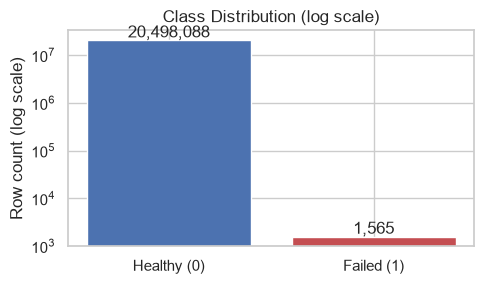

Imbalance ratio (healthy : failed) approx 13,098 : 1
This ratio is why threshold=0.5 and plain accuracy are misleading metrics here.


In [6]:
vc = raw_df["failure"].value_counts()
fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(["Healthy (0)", "Failed (1)"], [vc.get(0, 0), vc.get(1, 0)], color=["#4C72B0", "#C44E52"])
ax.set_yscale("log")
ax.set_title("Class Distribution (log scale)")
ax.set_ylabel("Row count (log scale)")
for i, v in enumerate([vc.get(0, 0), vc.get(1, 0)]):
    ax.text(i, v * 1.15, f"{v:,}", ha="center")
plt.tight_layout()
plt.show()
ratio = vc.get(0, 0) / max(vc.get(1, 1), 1)
print(f"Imbalance ratio (healthy : failed) approx {ratio:,.0f} : 1")
print("This ratio is why threshold=0.5 and plain accuracy are misleading metrics here.")

Using 9 base SMART attributes: ['smart_5_raw', 'smart_9_raw', 'smart_187_raw', 'smart_188_raw', 'smart_194_raw', 'smart_197_raw', 'smart_198_raw', 'smart_199_raw', 'smart_241_raw']


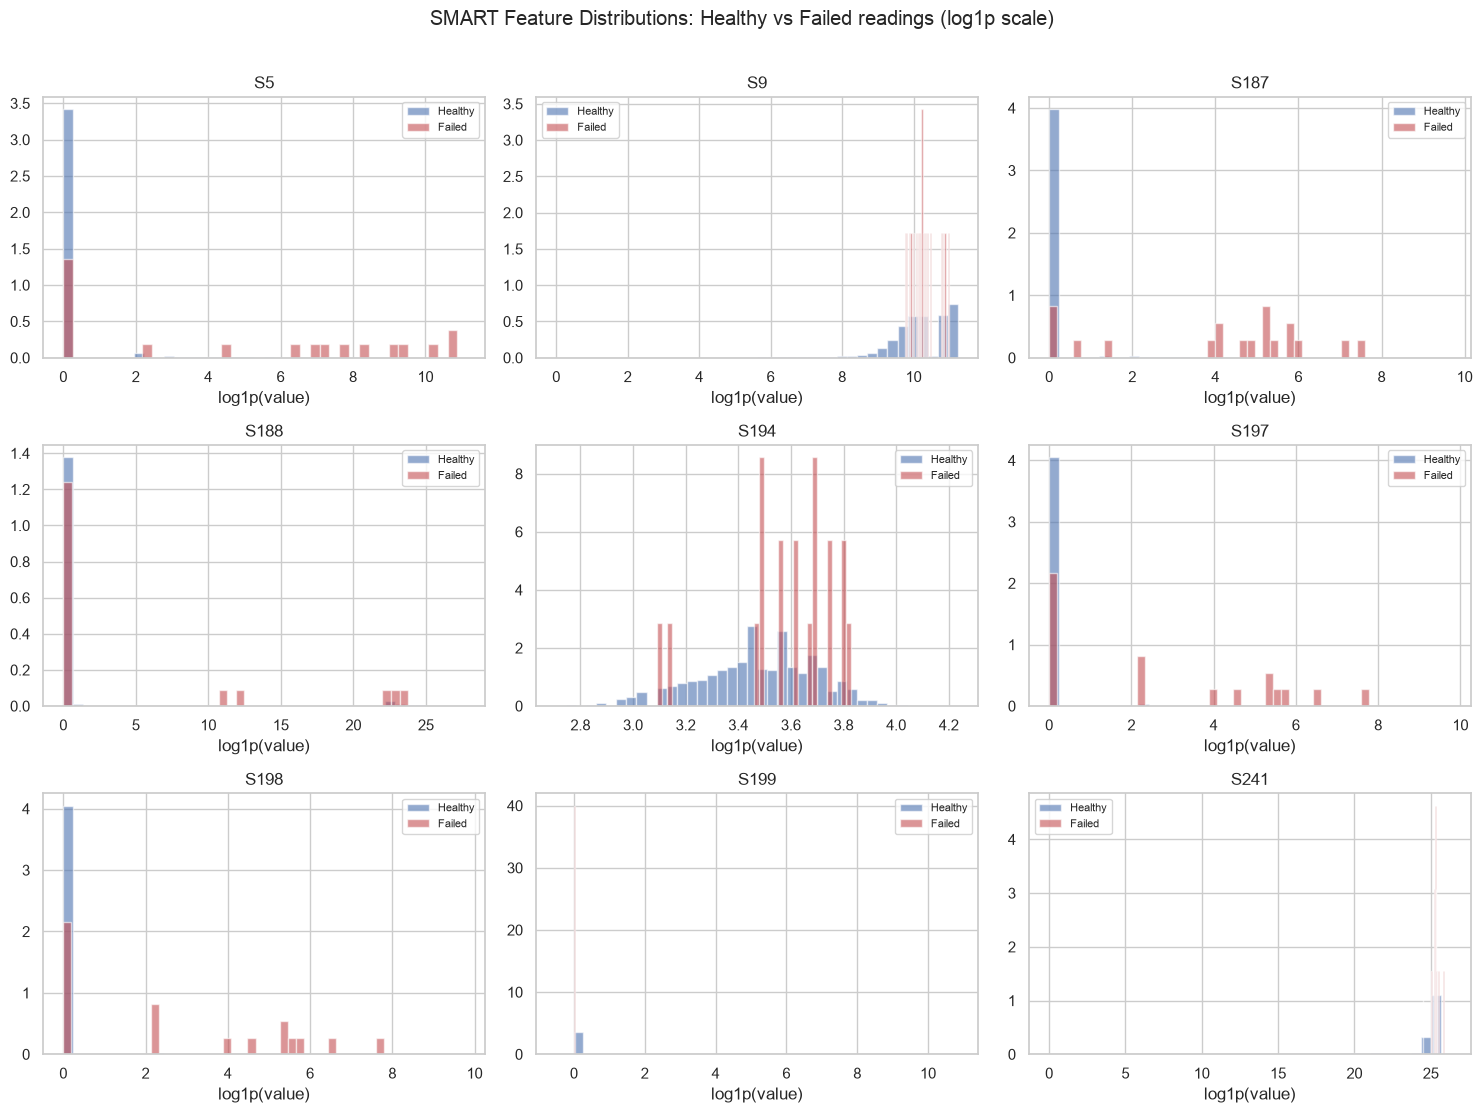

In [7]:
BASE_RAW_FEATURES = [
    "smart_5_raw",    # Reallocated Sectors Count
    "smart_9_raw",    # Power-On Hours
    "smart_187_raw",  # Reported Uncorrectable Errors
    "smart_188_raw",  # Command Timeout
    "smart_194_raw",  # Temperature (Celsius)
    "smart_197_raw",  # Current Pending Sector Count
    "smart_198_raw",  # Offline Uncorrectable Sector Count
    "smart_199_raw",  # UDMA CRC Error Count
    "smart_241_raw",  # Total LBAs Written
]
BASE_RAW_FEATURES = [c for c in BASE_RAW_FEATURES if c in raw_df.columns]
print(f"Using {len(BASE_RAW_FEATURES)} base SMART attributes: {BASE_RAW_FEATURES}")

sample_df = raw_df.sample(min(300_000, len(raw_df)), random_state=RANDOM_STATE)
fig, axes = plt.subplots(3, 3, figsize=(15, 11))
axes = axes.flatten()
for i, col in enumerate(BASE_RAW_FEATURES):
    for label, color in [(0, "#4C72B0"), (1, "#C44E52")]:
        vals = sample_df.loc[sample_df["failure"] == label, col].dropna()
        vals = np.log1p(vals.clip(lower=0))
        axes[i].hist(vals, bins=40, alpha=0.6, color=color, label=["Healthy", "Failed"][label], density=True)
    axes[i].set_title(col.replace("smart_", "S").replace("_raw", ""))
    axes[i].set_xlabel("log1p(value)")
    axes[i].legend(fontsize=8)
for j in range(len(BASE_RAW_FEATURES), len(axes)):
    axes[j].set_visible(False)
fig.suptitle("SMART Feature Distributions: Healthy vs Failed readings (log1p scale)", y=1.01)
plt.tight_layout()
plt.show()

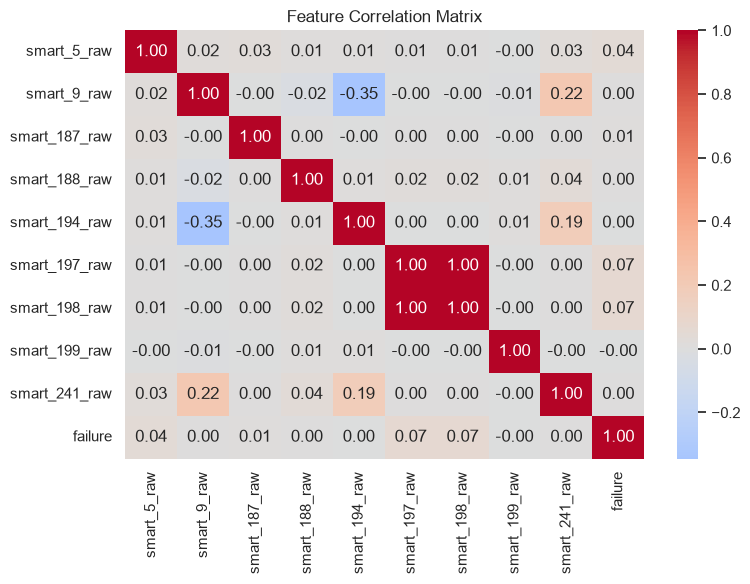

In [8]:
corr = raw_df[BASE_RAW_FEATURES + ["failure"]].corr()
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

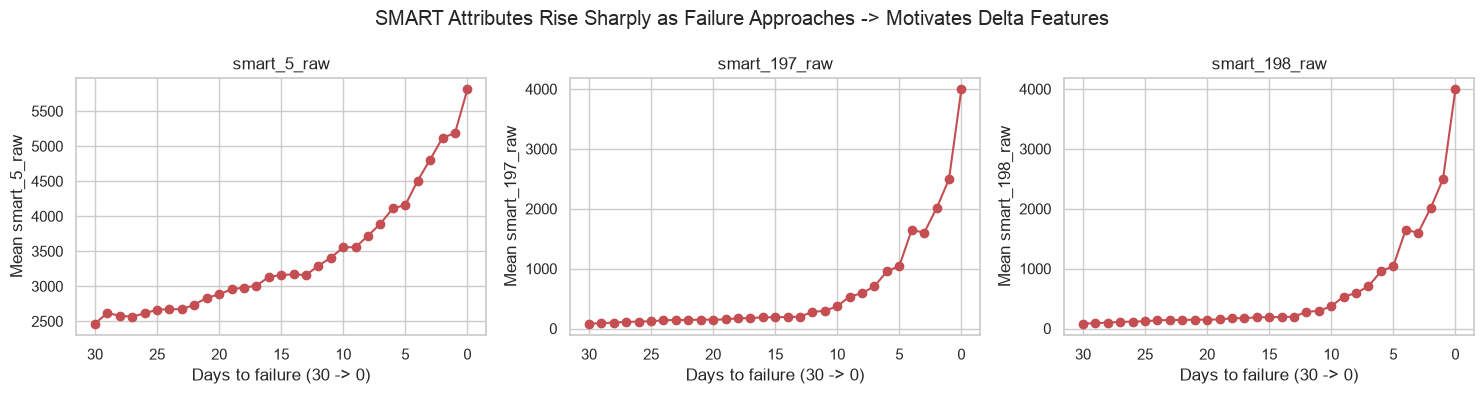

In [9]:
# --- Trend analysis: how do SMART values evolve as failure approaches? ---
# This is the empirical justification for the delta/rate-of-change features in Section 4.
failing_ids_eda = raw_df.loc[raw_df["failure"] == 1, "id"].unique()
trend_df = raw_df[raw_df["id"].isin(failing_ids_eda)].copy()
last_date = trend_df.groupby("id")["time"].transform("max")
trend_df["days_to_failure"] = (last_date - trend_df["time"]).dt.days
trend_df = trend_df[trend_df["days_to_failure"] <= 30]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["smart_5_raw", "smart_197_raw", "smart_198_raw"]):
    if col not in trend_df.columns:
        continue
    agg = trend_df.groupby("days_to_failure")[col].mean().sort_index(ascending=False)
    ax.plot(agg.index, agg.values, marker="o", color="#C44E52")
    ax.invert_xaxis()
    ax.set_xlabel("Days to failure (30 -> 0)")
    ax.set_ylabel(f"Mean {col}")
    ax.set_title(col)
fig.suptitle("SMART Attributes Rise Sharply as Failure Approaches -> Motivates Delta Features")
plt.tight_layout()
plt.show()

## 4. Feature Engineering — Rate-of-Change Features



In [10]:
df_feat = raw_df.sort_values(["id", "time"]).copy()

delta_cols = []
for col in BASE_RAW_FEATURES:
    delta_col = f"{col}_delta{DELTA_WINDOW_DAYS}"
    df_feat[delta_col] = df_feat.groupby("id")[col].diff(DELTA_WINDOW_DAYS)
    delta_cols.append(delta_col)

FEATURE_COLUMNS = BASE_RAW_FEATURES + delta_cols
print(f"Total feature count: {len(FEATURE_COLUMNS)}  ({len(BASE_RAW_FEATURES)} raw + {len(delta_cols)} delta)")
print(FEATURE_COLUMNS)

# Rows near the start of a drive's history won't have DELTA_WINDOW_DAYS of prior
# readings yet -> delta is NaN there. The imputer in Section 5 handles this
# (median-fills), which is a reasonable default: "no known trend yet".
print(f"\nRows with at least one missing delta feature: "
      f"{df_feat[delta_cols].isna().any(axis=1).mean() * 100:.1f}%")

Total feature count: 18  (9 raw + 9 delta)
['smart_5_raw', 'smart_9_raw', 'smart_187_raw', 'smart_188_raw', 'smart_194_raw', 'smart_197_raw', 'smart_198_raw', 'smart_199_raw', 'smart_241_raw', 'smart_5_raw_delta7', 'smart_9_raw_delta7', 'smart_187_raw_delta7', 'smart_188_raw_delta7', 'smart_194_raw_delta7', 'smart_197_raw_delta7', 'smart_198_raw_delta7', 'smart_199_raw_delta7', 'smart_241_raw_delta7']

Rows with at least one missing delta feature: 4.4%


## 5. Data Preprocessing

Three steps:
1. **Target engineering** — binary "at-risk" label: 1 if the drive fails within the
   next `FAILURE_HORIZON_DAYS` days, else 0.
2. **Leakage-free split** — split by *drive ID* with `GroupShuffleSplit` so no drive's
   readings appear in more than one partition (otherwise the model could "memorize"
   a drive it partially saw in training).
3. **Imputation & scaling** — median imputation, then `StandardScaler`, both fit on
   the training set only.

In [11]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer


def engineer_target(df, window_days):
    '''Binary label: 1 if this row is within `window_days` of that drive's failure date.'''
    df = df.copy()
    failure_dates = df.loc[df["failure"] == 1].groupby("id")["time"].max().to_dict()
    df["failure_date"] = df["id"].map(failure_dates)
    df["days_to_failure"] = (df["failure_date"] - df["time"]).dt.days
    df["target"] = df["days_to_failure"].between(0, window_days).astype(int)
    return df.drop(columns=["failure_date"])


df_labeled = engineer_target(df_feat, FAILURE_HORIZON_DAYS)
print(f"Positive rate after labeling ({FAILURE_HORIZON_DAYS}-day horizon): "
      f"{100 * df_labeled['target'].mean():.4f}%  "
      f"({df_labeled['target'].sum():,} / {len(df_labeled):,} rows)")

Positive rate after labeling (10-day horizon): 0.0790%  (16,193 / 20,499,653 rows)


In [12]:
gss1 = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
train_val_idx, test_idx = next(gss1.split(df_labeled, groups=df_labeled["id"]))
train_val_df, test_df = df_labeled.iloc[train_val_idx], df_labeled.iloc[test_idx]

gss2 = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=RANDOM_STATE)
train_idx, val_idx = next(gss2.split(train_val_df, groups=train_val_df["id"]))
train_df, val_df = train_val_df.iloc[train_idx], train_val_df.iloc[val_idx]

print(f"Train: {train_df.shape[0]:,} rows, {train_df['id'].nunique():,} drives, "
      f"{train_df['target'].sum():,} positives")
print(f"Val:   {val_df.shape[0]:,} rows, {val_df['id'].nunique():,} drives, "
      f"{val_df['target'].sum():,} positives")
print(f"Test:  {test_df.shape[0]:,} rows, {test_df['id'].nunique():,} drives, "
      f"{test_df['target'].sum():,} positives")
assert set(train_df["id"]) & set(val_df["id"]) == set()
assert set(train_df["id"]) & set(test_df["id"]) == set()
assert set(val_df["id"]) & set(test_df["id"]) == set()
print("\nNo drive appears in more than one split (leakage check passed).")

Train: 13,942,088 rows, 81,458 drives, 10,714 positives


Val:   2,459,059 rows, 14,376 drives, 2,020 positives


Test:  4,098,506 rows, 23,959 drives, 3,459 positives



No drive appears in more than one split (leakage check passed).


In [13]:
X_train, y_train = train_df[FEATURE_COLUMNS].copy(), train_df["target"].copy()
X_val, y_val = val_df[FEATURE_COLUMNS].copy(), val_df["target"].copy()
X_test, y_test = test_df[FEATURE_COLUMNS].copy(), test_df["target"].copy()

imputer = SimpleImputer(strategy="median")
X_train_imp = imputer.fit_transform(X_train)
X_val_imp = imputer.transform(X_val)
X_test_imp = imputer.transform(X_test)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imp)
X_val_scaled = scaler.transform(X_val_imp)
X_test_scaled = scaler.transform(X_test_imp)

n_pos, n_neg = int(y_train.sum()), int((y_train == 0).sum())
POS_WEIGHT = n_neg / max(n_pos, 1)
print(f"Training set -> positives: {n_pos:,}  negatives: {n_neg:,}  pos_weight: {POS_WEIGHT:.1f}")

Training set -> positives: 10,714  negatives: 13,931,374  pos_weight: 1300.3


## 6. Handling Class Imbalance



In [14]:
from torch.utils.data import WeightedRandomSampler

class_sample_count = np.array([n_neg, n_pos])
weight_per_class = 1.0 / class_sample_count
sample_weights = weight_per_class[y_train.values.astype(int)]
sample_weights = torch.tensor(sample_weights, dtype=torch.double)

train_sampler = WeightedRandomSampler(
    weights=sample_weights, num_samples=len(sample_weights), replacement=True
)
print("WeightedRandomSampler ready. Dataset size is UNCHANGED "
      f"({len(sample_weights):,} rows) -- only the sampling probability is adjusted.")

WeightedRandomSampler ready. Dataset size is UNCHANGED (13,942,088 rows) -- only the sampling probability is adjusted.


## 7. PyTorch Dataset & DataLoader

In [15]:
from torch import nn
from torch.utils.data import Dataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

BATCH_SIZE = 2048
NUM_WORKERS = 0  # 0 per the note below: spawn-based workers cannot pickle the
                 # Dataset classes defined in this kernel (macOS / Python 3.14), and
                 # with the tensors already resident in RAM they add overhead anyway.


class DriveDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        y_arr = y.values if hasattr(y, "values") else y
        self.y = torch.tensor(y_arr, dtype=torch.float32).unsqueeze(1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


train_dataset = DriveDataset(X_train_scaled, y_train)
val_dataset = DriveDataset(X_val_scaled, y_val)
test_dataset = DriveDataset(X_test_scaled, y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=train_sampler,
                           num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda"))
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda"))
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda"))

print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, "
      f"Test batches: {len(test_loader)}")

Using device: cpu


Train batches: 6808, Val batches: 1201, Test batches: 2002


## 8. Model Architecture

`DriveFailureDNN` is a configurable feed-forward network: `Linear -> BatchNorm ->
ReLU -> Dropout`, repeated, ending in a single logit for `BCEWithLogitsLoss`.
`FocalLoss` is implemented as an alternative loss function to compare against
class-weighted BCE.

In [16]:
class DriveFailureDNN(nn.Module):
    def __init__(self, input_dim, hidden_sizes=(64, 32), dropout=0.3):
        super().__init__()
        layers = []
        prev_dim = input_dim
        for h in hidden_sizes:
            layers += [nn.Linear(prev_dim, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)]
            prev_dim = h
        layers.append(nn.Linear(prev_dim, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


class FocalLoss(nn.Module):
    '''Focal loss for binary classification with logits.

    Down-weights easy (already well-classified) examples via (1-pt)**gamma so training
    focuses on hard/minority examples -- an alternative to class-weighted resampling.
    '''
    def __init__(self, alpha=0.25, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        bce = nn.functional.binary_cross_entropy_with_logits(logits, targets, reduction="none")
        probs = torch.sigmoid(logits)
        pt = probs * targets + (1 - probs) * (1 - targets)
        alpha_t = self.alpha * targets + (1 - self.alpha) * (1 - targets)
        loss = alpha_t * (1 - pt).pow(self.gamma) * bce
        return loss.mean()


_tmp = DriveFailureDNN(input_dim=len(FEATURE_COLUMNS)).to(device)
print(_tmp)
del _tmp

DriveFailureDNN(
  (net): Sequential(
    (0): Linear(in_features=18, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=32, out_features=1, bias=True)
  )
)


## 9. Training & Validation Function

`run_training()` trains with early stopping on **validation PR-AUC** (far more
informative than loss or accuracy on a dataset this imbalanced) and supports both loss
types so the same function powers the hyperparameter grid (Section 10) and the final
model (Section 11).

In [17]:
from sklearn.metrics import average_precision_score, f1_score
import copy


def evaluate_loader(model, loader, criterion):
    model.eval()
    total_loss, all_probs, all_targets = 0.0, [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)
            total_loss += loss.item() * xb.size(0)
            all_probs.append(torch.sigmoid(logits).cpu().numpy())
            all_targets.append(yb.cpu().numpy())
    probs = np.concatenate(all_probs).flatten()
    targets = np.concatenate(all_targets).flatten()
    avg_loss = total_loss / len(loader.dataset)
    pr_auc = average_precision_score(targets, probs)
    f1 = f1_score(targets, (probs > 0.5).astype(int), zero_division=0)
    return avg_loss, pr_auc, f1, probs, targets


def run_training(hidden_sizes, dropout, lr, loss_type="bce", pos_weight=POS_WEIGHT,
                  max_epochs=30, patience=5, verbose=True):
    model = DriveFailureDNN(input_dim=len(FEATURE_COLUMNS), hidden_sizes=hidden_sizes,
                             dropout=dropout).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=2)

    if loss_type == "focal":
        criterion = FocalLoss(alpha=0.25, gamma=2.0)
    else:
        criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight], device=device))

    history = {"train_loss": [], "val_loss": [], "val_pr_auc": [], "val_f1": []}
    best_pr_auc, best_state, epochs_no_improve = -1.0, None, 0

    for epoch in range(1, max_epochs + 1):
        model.train()
        running_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * xb.size(0)
        train_loss = running_loss / len(train_loader.dataset)

        val_loss, val_pr_auc, val_f1, _, _ = evaluate_loader(model, val_loader, criterion)
        scheduler.step(val_pr_auc)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_pr_auc"].append(val_pr_auc)
        history["val_f1"].append(val_f1)

        if verbose:
            print(f"Epoch {epoch:2d} | train_loss {train_loss:.4f} | val_loss {val_loss:.4f} "
                  f"| val PR-AUC {val_pr_auc:.4f} | val F1@0.5 {val_f1:.4f}")

        if val_pr_auc > best_pr_auc:
            best_pr_auc, best_state, epochs_no_improve = val_pr_auc, copy.deepcopy(model.state_dict()), 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                if verbose:
                    print(f"Early stopping at epoch {epoch} (best val PR-AUC: {best_pr_auc:.4f})")
                break

    model.load_state_dict(best_state)
    return model, history, best_pr_auc

## 10. Hyperparameter Tuning & Model Comparison

We compare architectures, learning rates, **and** the two imbalance-handling loss
strategies (`bce` with `pos_weight` vs. `focal`), ranked by validation **PR-AUC**. The
best configuration is carried forward for final training.

In [18]:
HYPERPARAM_GRID = [
    {"hidden_sizes": (32,),          "dropout": 0.2, "lr": 1e-3, "loss_type": "bce"},
    {"hidden_sizes": (64, 32),       "dropout": 0.3, "lr": 1e-3, "loss_type": "bce"},
    {"hidden_sizes": (128, 64, 32),  "dropout": 0.3, "lr": 1e-3, "loss_type": "bce"},
    {"hidden_sizes": (64, 32),       "dropout": 0.3, "lr": 1e-3, "loss_type": "focal"},
    {"hidden_sizes": (128, 64, 32),  "dropout": 0.3, "lr": 1e-3, "loss_type": "focal"},
    {"hidden_sizes": (64, 32),       "dropout": 0.4, "lr": 5e-4, "loss_type": "bce"},
]

tuning_results = []
tuning_epochs = 3 if QUICK_TEST else 10

for i, params in enumerate(HYPERPARAM_GRID, start=1):
    print(f"\n=== Config {i}/{len(HYPERPARAM_GRID)}: {params} ===")
    _, history, best_val_pr_auc = run_training(
        hidden_sizes=params["hidden_sizes"], dropout=params["dropout"], lr=params["lr"],
        loss_type=params["loss_type"], max_epochs=tuning_epochs, patience=3, verbose=False,
    )
    tuning_results.append({**params, "best_val_pr_auc": best_val_pr_auc})
    print(f"-> best val PR-AUC: {best_val_pr_auc:.4f}")

tuning_df = pd.DataFrame(tuning_results).sort_values("best_val_pr_auc", ascending=False).reset_index(drop=True)
print("\n" + tuning_df.to_string())


=== Config 1/6: {'hidden_sizes': (32,), 'dropout': 0.2, 'lr': 0.001, 'loss_type': 'bce'} ===


-> best val PR-AUC: 0.0521

=== Config 2/6: {'hidden_sizes': (64, 32), 'dropout': 0.3, 'lr': 0.001, 'loss_type': 'bce'} ===


-> best val PR-AUC: 0.1018

=== Config 3/6: {'hidden_sizes': (128, 64, 32), 'dropout': 0.3, 'lr': 0.001, 'loss_type': 'bce'} ===


-> best val PR-AUC: 0.1040

=== Config 4/6: {'hidden_sizes': (64, 32), 'dropout': 0.3, 'lr': 0.001, 'loss_type': 'focal'} ===


-> best val PR-AUC: 0.1584

=== Config 5/6: {'hidden_sizes': (128, 64, 32), 'dropout': 0.3, 'lr': 0.001, 'loss_type': 'focal'} ===


-> best val PR-AUC: 0.1544

=== Config 6/6: {'hidden_sizes': (64, 32), 'dropout': 0.4, 'lr': 0.0005, 'loss_type': 'bce'} ===


-> best val PR-AUC: 0.0929

    hidden_sizes  dropout      lr loss_type  best_val_pr_auc
0       (64, 32)      0.3  0.0010     focal         0.158434
1  (128, 64, 32)      0.3  0.0010     focal         0.154426
2  (128, 64, 32)      0.3  0.0010       bce         0.104042
3       (64, 32)      0.3  0.0010       bce         0.101835
4       (64, 32)      0.4  0.0005       bce         0.092945
5          (32,)      0.2  0.0010       bce         0.052054


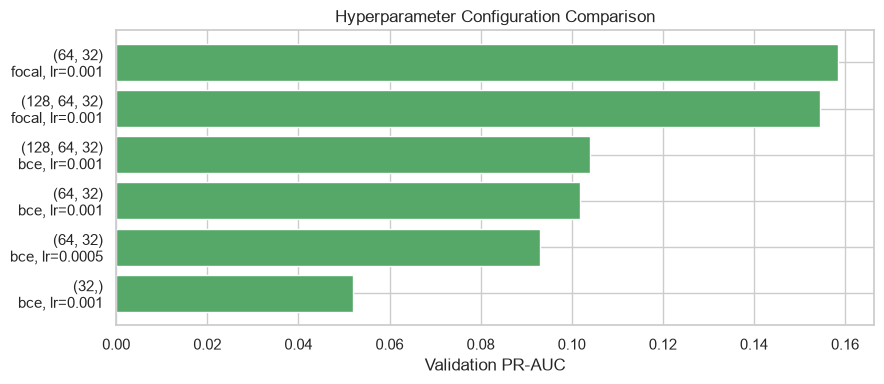

Selected best configuration: {'hidden_sizes': (64, 32), 'dropout': 0.3, 'lr': 0.001, 'loss_type': 'focal', 'best_val_pr_auc': 0.15843428584317049}


In [19]:
fig, ax = plt.subplots(figsize=(9, 4))
labels = [f"{r['hidden_sizes']}\n{r['loss_type']}, lr={r['lr']}" for _, r in tuning_df.iterrows()]
ax.barh(labels, tuning_df["best_val_pr_auc"], color="#55A868")
ax.set_xlabel("Validation PR-AUC")
ax.set_title("Hyperparameter Configuration Comparison")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

BEST_CONFIG = tuning_df.iloc[0].to_dict()
print("Selected best configuration:", BEST_CONFIG)

## 11. Final Model Training

Retrain with the best configuration, more epochs, and more patience, then inspect the
learning curves.

In [20]:
final_hidden = BEST_CONFIG["hidden_sizes"]
if not isinstance(final_hidden, tuple):
    final_hidden = tuple(final_hidden)

final_model, final_history, _ = run_training(
    hidden_sizes=final_hidden,
    dropout=BEST_CONFIG["dropout"],
    lr=BEST_CONFIG["lr"],
    loss_type=BEST_CONFIG["loss_type"],
    max_epochs=15 if QUICK_TEST else 60,
    patience=5 if QUICK_TEST else 10,
    verbose=True,
)

Epoch  1 | train_loss 0.0440 | val_loss 0.0387 | val PR-AUC 0.1347 | val F1@0.5 0.0396


Epoch  2 | train_loss 0.0413 | val_loss 0.0533 | val PR-AUC 0.1381 | val F1@0.5 0.0287


Epoch  3 | train_loss 0.0408 | val_loss 0.0571 | val PR-AUC 0.1390 | val F1@0.5 0.0298


Epoch  4 | train_loss 0.0404 | val_loss 0.0543 | val PR-AUC 0.1410 | val F1@0.5 0.0280


Epoch  5 | train_loss 0.0403 | val_loss 0.0565 | val PR-AUC 0.1434 | val F1@0.5 0.0300


...

Epoch 36 | train_loss 0.0373 | val_loss 0.0752 | val PR-AUC 0.1513 | val F1@0.5 0.0222


Epoch 37 | train_loss 0.0372 | val_loss 0.1896 | val PR-AUC 0.1459 | val F1@0.5 0.0020


Epoch 38 | train_loss 0.0373 | val_loss 0.0911 | val PR-AUC 0.1426 | val F1@0.5 0.0099


Epoch 39 | train_loss 0.0372 | val_loss 0.1009 | val PR-AUC 0.1477 | val F1@0.5 0.0069


Epoch 40 | train_loss 0.0373 | val_loss 0.0972 | val PR-AUC 0.1471 | val F1@0.5 0.0074
Early stopping at epoch 40 (best val PR-AUC: 0.1551)


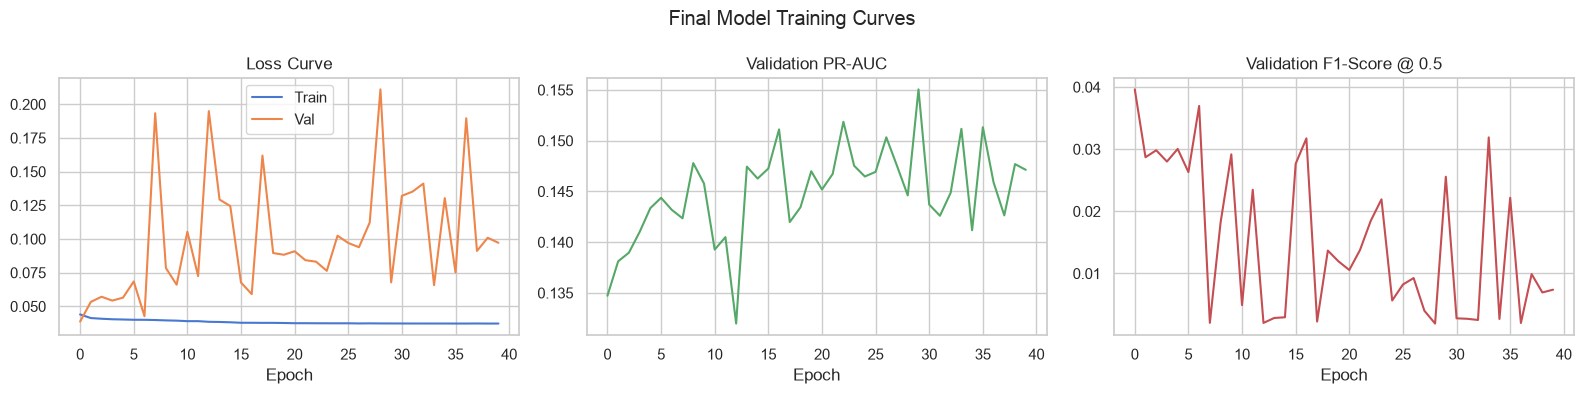

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(final_history["train_loss"], label="Train")
axes[0].plot(final_history["val_loss"], label="Val")
axes[0].set_title("Loss Curve")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(final_history["val_pr_auc"], color="#55A868")
axes[1].set_title("Validation PR-AUC")
axes[1].set_xlabel("Epoch")

axes[2].plot(final_history["val_f1"], color="#C44E52")
axes[2].set_title("Validation F1-Score @ 0.5")
axes[2].set_xlabel("Epoch")

plt.suptitle("Final Model Training Curves")
plt.tight_layout()
plt.show()

## 12. Performance Evaluation



In [22]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, classification_report,
    confusion_matrix, roc_curve, precision_recall_curve,
)

criterion_eval = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([POS_WEIGHT], device=device))
_, test_pr_auc, _, test_probs, test_targets = evaluate_loader(final_model, test_loader, criterion_eval)

preds_05 = (test_probs > 0.5).astype(int)
roc_auc = roc_auc_score(test_targets, test_probs)
pr_auc = average_precision_score(test_targets, test_probs)

print("=" * 55)
print("  TEST SET @ THRESHOLD = 0.5  (naive baseline, for comparison)")
print("=" * 55)
print(f" ROC-AUC:   {roc_auc:.4f}")
print(f" PR-AUC:    {pr_auc:.4f}")
print(f" Accuracy:  {accuracy_score(test_targets, preds_05):.4f}  <- misleading here, ignore")
print(f" Precision: {precision_score(test_targets, preds_05, zero_division=0):.4f}")
print(f" Recall:    {recall_score(test_targets, preds_05):.4f}")
print(f" F1-Score:  {f1_score(test_targets, preds_05):.4f}")
print()
print(classification_report(test_targets, preds_05, target_names=["Healthy", "At-risk"], zero_division=0))

  TEST SET @ THRESHOLD = 0.5  (naive baseline, for comparison)
 ROC-AUC:   0.8980
 PR-AUC:    0.1518
 Accuracy:  0.9514  <- misleading here, ignore
 Precision: 0.0124


 Recall:    0.7184
 F1-Score:  0.0243



              precision    recall  f1-score   support

     Healthy       1.00      0.95      0.98   4095047
     At-risk       0.01      0.72      0.02      3459

    accuracy                           0.95   4098506
   macro avg       0.51      0.84      0.50   4098506
weighted avg       1.00      0.95      0.97   4098506



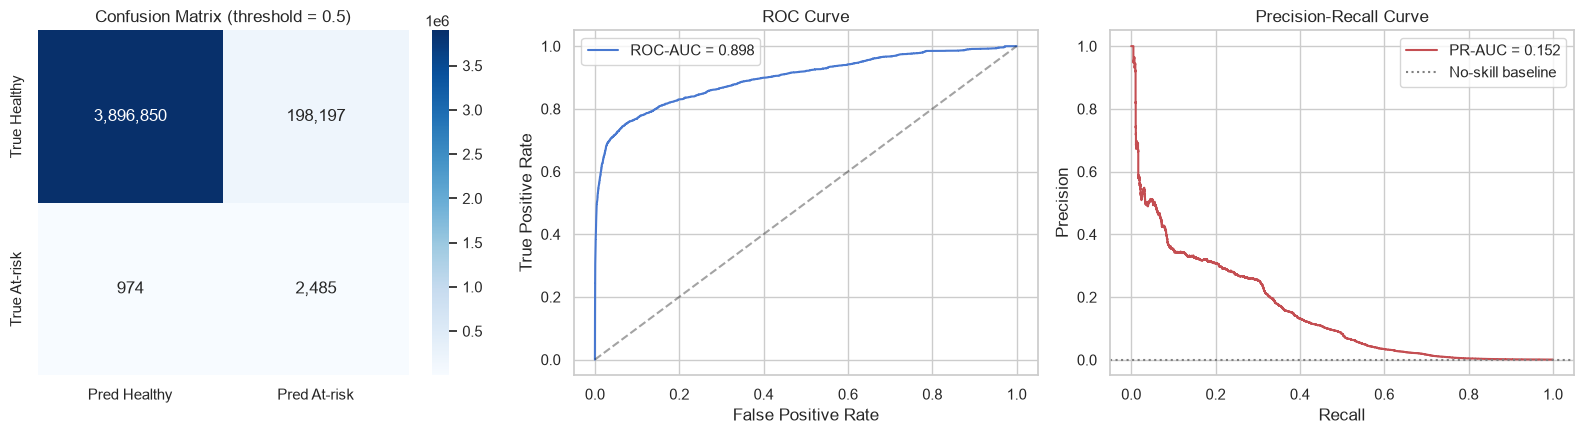

In [23]:
cm_05 = confusion_matrix(test_targets, preds_05)
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

sns.heatmap(cm_05, annot=True, fmt=",d", cmap="Blues", ax=axes[0],
            xticklabels=["Pred Healthy", "Pred At-risk"], yticklabels=["True Healthy", "True At-risk"])
axes[0].set_title("Confusion Matrix (threshold = 0.5)")

fpr, tpr, _ = roc_curve(test_targets, test_probs)
axes[1].plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.3f}")
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.4)
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve")
axes[1].legend()

prec_curve, rec_curve, _ = precision_recall_curve(test_targets, test_probs)
axes[2].plot(rec_curve, prec_curve, label=f"PR-AUC = {pr_auc:.3f}", color="#C44E52")
axes[2].axhline(test_targets.mean(), color="grey", linestyle=":", label="No-skill baseline")
axes[2].set_xlabel("Recall")
axes[2].set_ylabel("Precision")
axes[2].set_title("Precision-Recall Curve")
axes[2].legend()

plt.tight_layout()
plt.show()

## 13. Threshold Tuning (on the VALIDATION set only)



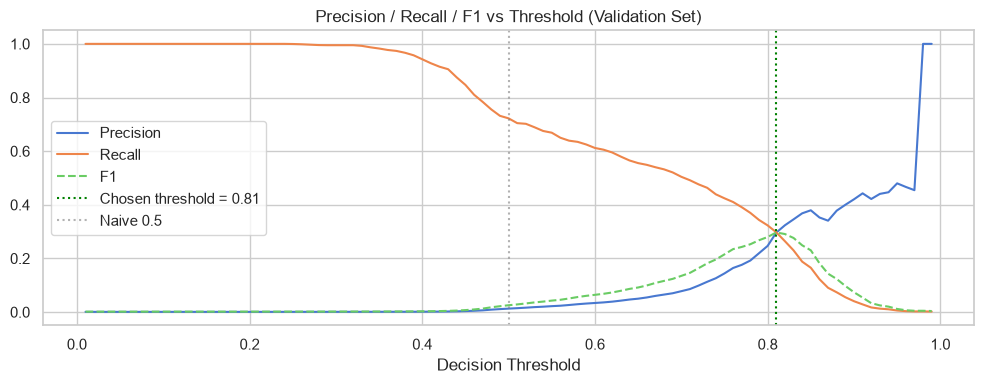

Best threshold by validation F1: 0.81
  -> val precision: 0.2964, val recall: 0.2975, val F1: 0.2969

If your priority is catching every possible failure (recall) at the cost of more false
alarms, pick a LOWER threshold from the plot above; if you want fewer, higher-confidence
alerts, pick a HIGHER one. BEST_THRESHOLD here optimizes F1 as a balanced default.


In [24]:
_, _, _, val_probs, val_targets = evaluate_loader(final_model, val_loader, criterion_eval)

thresholds = np.arange(0.01, 0.991, 0.01)
val_th_results = []
for t in thresholds:
    p_t = (val_probs > t).astype(int)
    val_th_results.append({
        "threshold": t,
        "precision": precision_score(val_targets, p_t, zero_division=0),
        "recall": recall_score(val_targets, p_t, zero_division=0),
        "f1": f1_score(val_targets, p_t, zero_division=0),
    })
val_th_df = pd.DataFrame(val_th_results)
best_row = val_th_df.loc[val_th_df["f1"].idxmax()]
BEST_THRESHOLD = float(best_row["threshold"])

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(val_th_df["threshold"], val_th_df["precision"], label="Precision")
ax.plot(val_th_df["threshold"], val_th_df["recall"], label="Recall")
ax.plot(val_th_df["threshold"], val_th_df["f1"], label="F1", linestyle="--")
ax.axvline(BEST_THRESHOLD, color="green", linestyle=":", label=f"Chosen threshold = {BEST_THRESHOLD:.2f}")
ax.axvline(0.5, color="grey", linestyle=":", alpha=0.6, label="Naive 0.5")
ax.set_xlabel("Decision Threshold")
ax.set_title("Precision / Recall / F1 vs Threshold (Validation Set)")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Best threshold by validation F1: {BEST_THRESHOLD:.2f}")
print(f"  -> val precision: {best_row['precision']:.4f}, val recall: {best_row['recall']:.4f}, "
      f"val F1: {best_row['f1']:.4f}")
print()
print("If your priority is catching every possible failure (recall) at the cost of more false")
print("alarms, pick a LOWER threshold from the plot above; if you want fewer, higher-confidence")
print("alerts, pick a HIGHER one. BEST_THRESHOLD here optimizes F1 as a balanced default.")

  TEST SET @ TUNED THRESHOLD = 0.81  (final, honest numbers)
 ROC-AUC:   0.8980   (threshold-independent, unchanged)
 PR-AUC:    0.1518   (threshold-independent, unchanged)
 Accuracy:  0.9987
 Precision: 0.2627


 Recall:    0.2700
 F1-Score:  0.2663



              precision    recall  f1-score   support

     Healthy       1.00      1.00      1.00   4095047
     At-risk       0.26      0.27      0.27      3459

    accuracy                           1.00   4098506
   macro avg       0.63      0.63      0.63   4098506
weighted avg       1.00      1.00      1.00   4098506



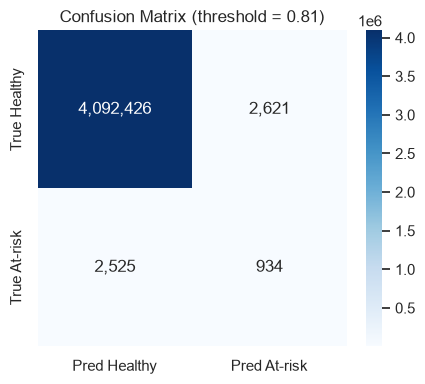

   Metric  Threshold = 0.5 (naive)  Threshold = 0.81 (tuned)
Precision                   0.0124                    0.2627
   Recall                   0.7184                    0.2700
 F1-Score                   0.0243                    0.2663


In [25]:
final_preds = (test_probs > BEST_THRESHOLD).astype(int)
cm_final = confusion_matrix(test_targets, final_preds)

print("=" * 55)
print(f"  TEST SET @ TUNED THRESHOLD = {BEST_THRESHOLD:.2f}  (final, honest numbers)")
print("=" * 55)
print(f" ROC-AUC:   {roc_auc:.4f}   (threshold-independent, unchanged)")
print(f" PR-AUC:    {pr_auc:.4f}   (threshold-independent, unchanged)")
print(f" Accuracy:  {accuracy_score(test_targets, final_preds):.4f}")
print(f" Precision: {precision_score(test_targets, final_preds, zero_division=0):.4f}")
print(f" Recall:    {recall_score(test_targets, final_preds):.4f}")
print(f" F1-Score:  {f1_score(test_targets, final_preds):.4f}")
print()
print(classification_report(test_targets, final_preds, target_names=["Healthy", "At-risk"], zero_division=0))

fig, ax = plt.subplots(figsize=(4.5, 4))
sns.heatmap(cm_final, annot=True, fmt=",d", cmap="Blues", ax=ax,
            xticklabels=["Pred Healthy", "Pred At-risk"], yticklabels=["True Healthy", "True At-risk"])
ax.set_title(f"Confusion Matrix (threshold = {BEST_THRESHOLD:.2f})")
plt.tight_layout()
plt.show()

comparison = pd.DataFrame({
    "Metric": ["Precision", "Recall", "F1-Score"],
    "Threshold = 0.5 (naive)": [
        precision_score(test_targets, preds_05, zero_division=0),
        recall_score(test_targets, preds_05),
        f1_score(test_targets, preds_05),
    ],
    f"Threshold = {BEST_THRESHOLD:.2f} (tuned)": [
        precision_score(test_targets, final_preds, zero_division=0),
        recall_score(test_targets, final_preds),
        f1_score(test_targets, final_preds),
    ],
}).round(4)
print(comparison.to_string(index=False))

## 14. Business-Relevant Evaluation: Precision@K / Lift


top_%_flagged  n_flagged  precision_at_k  recall_at_k
         0.1%       4098          0.2533       0.3001
         0.5%      20492          0.0842       0.4987
         1.0%      40985          0.0471       0.5577
         2.0%      81970          0.0269       0.6372
         5.0%     204925          0.0121       0.7193
        10.0%     409850          0.0065       0.7687

Overall base rate (random-flagging precision): 0.0844%


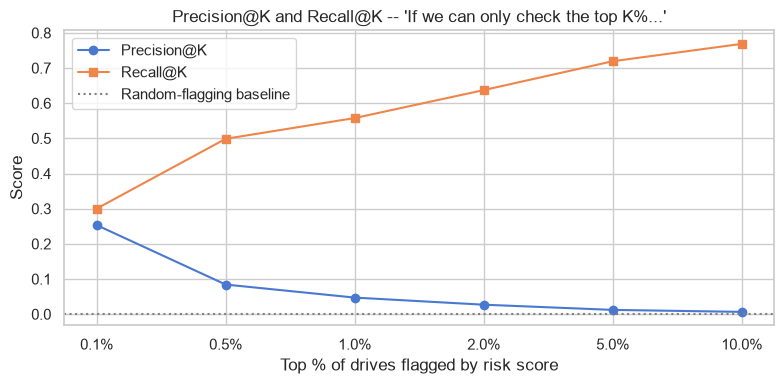

In [26]:
order = np.argsort(-test_probs)
sorted_targets = test_targets[order]
n = len(sorted_targets)

k_fractions = [0.001, 0.005, 0.01, 0.02, 0.05, 0.10]
rows = []
for k in k_fractions:
    k_n = max(int(n * k), 1)
    flagged = sorted_targets[:k_n]
    precision_at_k = flagged.mean()
    recall_at_k = flagged.sum() / max(sorted_targets.sum(), 1)
    rows.append({"top_%_flagged": f"{k*100:.1f}%", "n_flagged": k_n,
                  "precision_at_k": round(precision_at_k, 4), "recall_at_k": round(recall_at_k, 4)})

precision_at_k_df = pd.DataFrame(rows)
print(precision_at_k_df.to_string(index=False))
print(f"\nOverall base rate (random-flagging precision): {test_targets.mean():.4%}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(precision_at_k_df["top_%_flagged"], precision_at_k_df["precision_at_k"], marker="o", label="Precision@K")
ax.plot(precision_at_k_df["top_%_flagged"], precision_at_k_df["recall_at_k"], marker="s", label="Recall@K")
ax.axhline(test_targets.mean(), color="grey", linestyle=":", label="Random-flagging baseline")
ax.set_xlabel("Top % of drives flagged by risk score")
ax.set_ylabel("Score")
ax.set_title("Precision@K and Recall@K -- 'If we can only check the top K%...'")
ax.legend()
plt.tight_layout()
plt.show()

## 15. Prediction Demo

A quick illustration of what an individual prediction looks like, using the tuned
threshold from Section 13.

In [27]:
rng = np.random.RandomState(RANDOM_STATE)
demo_indices = rng.choice(len(test_dataset), size=min(8, len(test_dataset)), replace=False)
final_model.eval()
with torch.no_grad():
    demo_X = torch.stack([test_dataset[i][0] for i in demo_indices]).to(device)
    demo_y = torch.stack([test_dataset[i][1] for i in demo_indices]).cpu().numpy().flatten()
    demo_probs = torch.sigmoid(final_model(demo_X)).cpu().numpy().flatten()

demo_preds = (demo_probs > BEST_THRESHOLD).astype(int)
demo_result = pd.DataFrame({
    "True label": ["At-risk" if t else "Healthy" for t in demo_y.astype(int)],
    "Failure probability": [f"{p:.4f}" for p in demo_probs],
    f"Predicted (thr={BEST_THRESHOLD:.2f})": ["At-risk" if p else "Healthy" for p in demo_preds],
    "Correct?": ["Yes" if a == b else "No" for a, b in zip(demo_y.astype(int), demo_preds)],
})
demo_result

,True label,Failure probability,Predicted (thr=0.81),Correct?
0,Healthy,0.4165,Healthy,Yes
1,Healthy,0.3314,Healthy,Yes
2,Healthy,0.3790,Healthy,Yes
3,Healthy,0.4103,Healthy,Yes
4,Healthy,0.4041,Healthy,Yes
5,Healthy,0.3996,Healthy,Yes
6,Healthy,0.3505,Healthy,Yes
7,Healthy,0.4412,Healthy,Yes


## 16. Saving the Model & Preprocessing Config

Save the classifier weights and a JSON config with everything needed to reproduce
inference: feature list, scaler/imputer parameters, architecture, chosen threshold.

In [28]:
import json

torch.save(final_model.state_dict(), f"{MODELS_DIR}/backblaze_drive_failure_dnn.pth")

best_hidden = list(final_hidden)
preprocessing_config = {
    "feature_columns": FEATURE_COLUMNS,
    "base_raw_features": BASE_RAW_FEATURES,
    "delta_window_days": DELTA_WINDOW_DAYS,
    "failure_horizon_days": FAILURE_HORIZON_DAYS,
    "best_config": {
        "hidden_sizes": best_hidden,
        "dropout": float(BEST_CONFIG["dropout"]),
        "lr": float(BEST_CONFIG["lr"]),
        "loss_type": BEST_CONFIG["loss_type"],
    },
    "pos_weight": float(POS_WEIGHT),
    "decision_threshold": BEST_THRESHOLD,
    "scaler_mean": scaler.mean_.tolist(),
    "scaler_scale": scaler.scale_.tolist(),
    "imputer_statistics": imputer.statistics_.tolist(),
    "test_metrics": {
        "roc_auc": float(roc_auc),
        "pr_auc": float(pr_auc),
        "precision": float(precision_score(test_targets, final_preds, zero_division=0)),
        "recall": float(recall_score(test_targets, final_preds)),
        "f1": float(f1_score(test_targets, final_preds)),
    },
}

with open(f"{MODELS_DIR}/backblaze_preprocessing_config.json", "w") as f:
    json.dump(preprocessing_config, f, indent=2)

print(f"Saved: {MODELS_DIR}/backblaze_drive_failure_dnn.pth")
print(f"Saved: {MODELS_DIR}/backblaze_preprocessing_config.json")

Saved: backblaze_drive_failure_dnn.pth
Saved: backblaze_preprocessing_config.json


## 16b. Alternative Model: Classifier




In [29]:
from xgboost import XGBClassifier

# Train on the GPU when there is one; predict back on the CPU, because the feature
# tables are NumPy arrays in host memory and a GPU booster would only copy them over.
XGB_DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Reuse the exact same imputed features / target / splits as the DNN classifier
# (X_train_imp, X_val_imp, X_test_imp, y_train, y_val, y_test come from Section 5).
# No scaling needed -- tree-based models are invariant to monotonic feature scaling.

xgb_clf = XGBClassifier(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=POS_WEIGHT,   # same imbalance handling role as WeightedRandomSampler/focal loss
    eval_metric="aucpr",
    early_stopping_rounds=30,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    tree_method="hist",
    device=XGB_DEVICE,
)

xgb_clf.fit(
    X_train_imp, y_train,
    eval_set=[(X_val_imp, y_val)],
    verbose=False,
)
xgb_clf.set_params(device="cpu")

print(f"XGBoost classifier trained. Best iteration: {xgb_clf.best_iteration}")


XGBoost classifier trained. Best iteration: 74


In [30]:
# Threshold tuning on the VALIDATION set only -- identical protocol to Section 13
xgb_val_probs = xgb_clf.predict_proba(X_val_imp)[:, 1]
xgb_test_probs = xgb_clf.predict_proba(X_test_imp)[:, 1]

xgb_thresholds = np.arange(0.01, 0.991, 0.01)
xgb_val_th_results = []
for t in xgb_thresholds:
    p_t = (xgb_val_probs > t).astype(int)
    xgb_val_th_results.append({
        "threshold": t,
        "precision": precision_score(y_val, p_t, zero_division=0),
        "recall": recall_score(y_val, p_t, zero_division=0),
        "f1": f1_score(y_val, p_t, zero_division=0),
    })
xgb_val_th_df = pd.DataFrame(xgb_val_th_results)
xgb_best_row = xgb_val_th_df.loc[xgb_val_th_df["f1"].idxmax()]
XGB_BEST_THRESHOLD = float(xgb_best_row["threshold"])

print(f"XGBoost best threshold by validation F1: {XGB_BEST_THRESHOLD:.2f}")
print(f"  -> val precision: {xgb_best_row['precision']:.4f}, val recall: {xgb_best_row['recall']:.4f}, "
      f"val F1: {xgb_best_row['f1']:.4f}")


XGBoost best threshold by validation F1: 0.98
  -> val precision: 0.3043, val recall: 0.3025, val F1: 0.3034


  XGBOOST -- TEST SET @ TUNED THRESHOLD = 0.98
 ROC-AUC:   0.9040
 PR-AUC:    0.1564
 Accuracy:  0.9987


 Precision: 0.2497


 Recall:    0.2585


 F1-Score:  0.2540



              precision    recall  f1-score   support

     Healthy       1.00      1.00      1.00   4095047
     At-risk       0.25      0.26      0.25      3459

    accuracy                           1.00   4098506
   macro avg       0.62      0.63      0.63   4098506
weighted avg       1.00      1.00      1.00   4098506



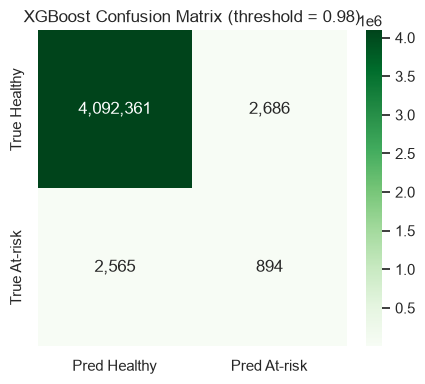

In [31]:
# Test-set evaluation @ tuned threshold -- same metrics as Section 12/13 for the DNN
xgb_roc_auc = roc_auc_score(y_test, xgb_test_probs)
xgb_pr_auc = average_precision_score(y_test, xgb_test_probs)
xgb_final_preds = (xgb_test_probs > XGB_BEST_THRESHOLD).astype(int)

print("=" * 55)
print(f"  XGBOOST -- TEST SET @ TUNED THRESHOLD = {XGB_BEST_THRESHOLD:.2f}")
print("=" * 55)
print(f" ROC-AUC:   {xgb_roc_auc:.4f}")
print(f" PR-AUC:    {xgb_pr_auc:.4f}")
print(f" Accuracy:  {accuracy_score(y_test, xgb_final_preds):.4f}")
print(f" Precision: {precision_score(y_test, xgb_final_preds, zero_division=0):.4f}")
print(f" Recall:    {recall_score(y_test, xgb_final_preds):.4f}")
print(f" F1-Score:  {f1_score(y_test, xgb_final_preds):.4f}")
print()
print(classification_report(y_test, xgb_final_preds, target_names=["Healthy", "At-risk"], zero_division=0))

xgb_cm = confusion_matrix(y_test, xgb_final_preds)
fig, ax = plt.subplots(figsize=(4.5, 4))
sns.heatmap(xgb_cm, annot=True, fmt=",d", cmap="Greens", ax=ax,
            xticklabels=["Pred Healthy", "Pred At-risk"], yticklabels=["True Healthy", "True At-risk"])
ax.set_title(f"XGBoost Confusion Matrix (threshold = {XGB_BEST_THRESHOLD:.2f})")
plt.tight_layout()
plt.show()


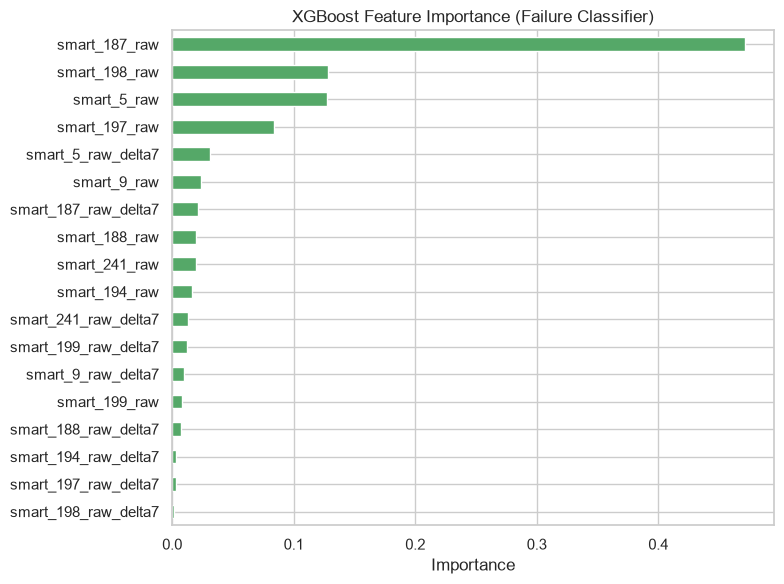

In [32]:
# Feature importance -- a natural bonus XGBoost gives "for free" vs. the DNN
importances = pd.Series(xgb_clf.feature_importances_, index=FEATURE_COLUMNS).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 6))
importances.plot(kind="barh", ax=ax, color="#55A868")
ax.invert_yaxis()
ax.set_title("XGBoost Feature Importance (Failure Classifier)")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()


In [33]:
# Direct comparison: DNN vs. XGBoost, same test set, same metrics
clf_comparison_df = pd.DataFrame({
    "Metric": ["ROC-AUC", "PR-AUC", "Precision", "Recall", "F1-Score"],
    "DNN (Section 12-13)": [roc_auc, pr_auc,
                             precision_score(test_targets, final_preds, zero_division=0),
                             recall_score(test_targets, final_preds),
                             f1_score(test_targets, final_preds)],
    "XGBoost": [xgb_roc_auc, xgb_pr_auc,
                precision_score(y_test, xgb_final_preds, zero_division=0),
                recall_score(y_test, xgb_final_preds),
                f1_score(y_test, xgb_final_preds)],
}).round(4)
clf_comparison_df["Winner"] = np.where(
    clf_comparison_df["XGBoost"] > clf_comparison_df["DNN (Section 12-13)"], "XGBoost",
    np.where(clf_comparison_df["XGBoost"] < clf_comparison_df["DNN (Section 12-13)"], "DNN", "Tie")
)
print(clf_comparison_df.to_string(index=False))


   Metric  DNN (Section 12-13)  XGBoost  Winner
  ROC-AUC               0.8980   0.9040 XGBoost
   PR-AUC               0.1518   0.1564 XGBoost
Precision               0.2627   0.2497     DNN
   Recall               0.2700   0.2585     DNN
 F1-Score               0.2663   0.2540     DNN


In [34]:
xgb_clf.save_model(f"{MODELS_DIR}/backblaze_drive_failure_xgb.json")
print(f"Saved: {MODELS_DIR}/backblaze_drive_failure_xgb.json")


Saved: backblaze_drive_failure_xgb.json


---
# Part 2: Remaining Useful Life (RUL) Regression

we train a
separate regression DNN to estimate **exactly how many days** remain until failure
useful for prioritizing maintenance among drives already flagged as at-risk.



In [35]:
failing_ids_rul = raw_df.loc[raw_df["failure"] == 1, "id"].unique()
rul_df = df_feat[df_feat["id"].isin(failing_ids_rul)].copy()

failure_dates = rul_df.loc[rul_df["failure"] == 1].groupby("id")["time"].max().to_dict()
rul_df["failure_date"] = rul_df["id"].map(failure_dates)
rul_df["days_to_failure"] = (rul_df["failure_date"] - rul_df["time"]).dt.days
rul_df = rul_df[(rul_df["days_to_failure"] >= 0) & (rul_df["days_to_failure"] <= RUL_HORIZON_DAYS)]
rul_df["rul_target"] = rul_df["days_to_failure"].astype(float)
rul_df = rul_df.drop(columns=["failure_date"])

print(f"RUL dataset: {rul_df.shape[0]:,} rows from {rul_df['id'].nunique():,} failed drives")
print(f"RUL target range: 0 to {RUL_HORIZON_DAYS} days, mean = {rul_df['rul_target'].mean():.1f} days")

RUL dataset: 80,655 rows from 1,565 failed drives
RUL target range: 0 to 60 days, mean = 28.6 days


In [36]:
rul_gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
rul_train_val_idx, rul_test_idx = next(rul_gss.split(rul_df, groups=rul_df["id"]))
rul_train_val_df, rul_test_df = rul_df.iloc[rul_train_val_idx], rul_df.iloc[rul_test_idx]

rul_gss2 = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=RANDOM_STATE)
rul_train_idx, rul_val_idx = next(rul_gss2.split(rul_train_val_df, groups=rul_train_val_df["id"]))
rul_train_df, rul_val_df = rul_train_val_df.iloc[rul_train_idx], rul_train_val_df.iloc[rul_val_idx]

print(f"RUL Train: {rul_train_df.shape}, Val: {rul_val_df.shape}, Test: {rul_test_df.shape}")

RUL Train: (55495, 24), Val: (9141, 24), Test: (16019, 24)


In [37]:
rul_imputer = SimpleImputer(strategy="median")
rul_scaler = StandardScaler()

X_rul_train = rul_scaler.fit_transform(rul_imputer.fit_transform(rul_train_df[FEATURE_COLUMNS]))
X_rul_val = rul_scaler.transform(rul_imputer.transform(rul_val_df[FEATURE_COLUMNS]))
X_rul_test = rul_scaler.transform(rul_imputer.transform(rul_test_df[FEATURE_COLUMNS]))

y_rul_train = rul_train_df["rul_target"].values.astype(np.float32)
y_rul_val = rul_val_df["rul_target"].values.astype(np.float32)
y_rul_test = rul_test_df["rul_target"].values.astype(np.float32)

print(f"X_rul_train: {X_rul_train.shape}, y_rul_train mean: {y_rul_train.mean():.1f} days")

X_rul_train: (55495, 18), y_rul_train mean: 28.7 days


In [38]:
class RULDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


rul_train_dataset = RULDataset(X_rul_train, y_rul_train)
rul_val_dataset = RULDataset(X_rul_val, y_rul_val)
rul_test_dataset = RULDataset(X_rul_test, y_rul_test)

rul_train_loader = DataLoader(rul_train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                               num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda"))
rul_val_loader = DataLoader(rul_val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                             num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda"))
rul_test_loader = DataLoader(rul_test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda"))
print(f"RUL train batches: {len(rul_train_loader)}")

RUL train batches: 28


In [39]:
class DriveRULDNN(nn.Module):
    def __init__(self, input_dim, hidden_sizes=(128, 64, 32), dropout=0.3):
        super().__init__()
        layers = []
        prev_dim = input_dim
        for h in hidden_sizes:
            layers += [nn.Linear(prev_dim, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)]
            prev_dim = h
        layers.append(nn.Linear(prev_dim, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


print(DriveRULDNN(input_dim=len(FEATURE_COLUMNS)))

DriveRULDNN(
  (net): Sequential(
    (0): Linear(in_features=18, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [40]:
def evaluate_rul_loader(model, loader, criterion):
    model.eval()
    total_loss, all_preds, all_targets_r = 0.0, [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            out = model(xb)
            loss = criterion(out, yb)
            total_loss += loss.item() * xb.size(0)
            all_preds.append(out.cpu().numpy())
            all_targets_r.append(yb.cpu().numpy())
    preds_r = np.concatenate(all_preds).flatten()
    targets_r = np.concatenate(all_targets_r).flatten()
    mae = np.mean(np.abs(preds_r - targets_r))
    return total_loss / len(loader.dataset), mae


def run_rul_training(hidden_sizes, dropout, lr, max_epochs=50, patience=5, verbose=True):
    model = DriveRULDNN(input_dim=len(FEATURE_COLUMNS), hidden_sizes=hidden_sizes, dropout=dropout).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)
    criterion = nn.SmoothL1Loss()

    history = {"train_loss": [], "val_loss": [], "val_mae": []}
    best_mae, best_state, epochs_no_improve = float("inf"), None, 0

    for epoch in range(1, max_epochs + 1):
        model.train()
        running_loss = 0.0
        for xb, yb in rul_train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            out = model(xb)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * xb.size(0)
        train_loss = running_loss / len(rul_train_loader.dataset)

        val_loss, val_mae = evaluate_rul_loader(model, rul_val_loader, criterion)
        scheduler.step(val_mae)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_mae"].append(val_mae)

        if verbose:
            print(f"Epoch {epoch:2d} | train loss {train_loss:.3f} | val MAE {val_mae:.3f} days")

        if val_mae < best_mae:
            best_mae, best_state, epochs_no_improve = val_mae, copy.deepcopy(model.state_dict()), 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                if verbose:
                    print(f"Early stopping at epoch {epoch} (best val MAE: {best_mae:.2f})")
                break

    model.load_state_dict(best_state)
    return model, history, best_mae

In [41]:
RUL_HYPERPARAM_GRID = [
    {"hidden_sizes": (64, 32), "dropout": 0.3, "lr": 1e-3},
    {"hidden_sizes": (128, 64, 32), "dropout": 0.3, "lr": 1e-3},
    {"hidden_sizes": (64, 32), "dropout": 0.4, "lr": 5e-4},
]

rul_tuning_results = []
rul_tuning_epochs = 3 if QUICK_TEST else 10

for i, params in enumerate(RUL_HYPERPARAM_GRID, start=1):
    print(f"\n=== RUL Config {i}/{len(RUL_HYPERPARAM_GRID)}: {params} ===")
    _, history, best_val_mae = run_rul_training(
        hidden_sizes=params["hidden_sizes"], dropout=params["dropout"], lr=params["lr"],
        max_epochs=rul_tuning_epochs, patience=3, verbose=False,
    )
    rul_tuning_results.append({**params, "best_val_mae_days": best_val_mae})
    print(f"-> best val MAE: {best_val_mae:.2f} days")

rul_tuning_df = pd.DataFrame(rul_tuning_results).sort_values("best_val_mae_days").reset_index(drop=True)
RUL_BEST_CONFIG = rul_tuning_df.iloc[0].to_dict()
print(f"\nSelected best RUL configuration: {RUL_BEST_CONFIG}")


=== RUL Config 1/3: {'hidden_sizes': (64, 32), 'dropout': 0.3, 'lr': 0.001} ===


-> best val MAE: 21.47 days

=== RUL Config 2/3: {'hidden_sizes': (128, 64, 32), 'dropout': 0.3, 'lr': 0.001} ===


-> best val MAE: 20.76 days

=== RUL Config 3/3: {'hidden_sizes': (64, 32), 'dropout': 0.4, 'lr': 0.0005} ===


-> best val MAE: 25.58 days

Selected best RUL configuration: {'hidden_sizes': (128, 64, 32), 'dropout': 0.3, 'lr': 0.001, 'best_val_mae_days': 20.761308670043945}


In [42]:
rul_hidden = RUL_BEST_CONFIG["hidden_sizes"]
if not isinstance(rul_hidden, tuple):
    rul_hidden = tuple(rul_hidden)

final_rul_model, rul_history, _ = run_rul_training(
    hidden_sizes=rul_hidden,
    dropout=RUL_BEST_CONFIG["dropout"],
    lr=RUL_BEST_CONFIG["lr"],
    max_epochs=15 if QUICK_TEST else 80,
    patience=5 if QUICK_TEST else 10,
    verbose=True,
)

Epoch  1 | train loss 28.220 | val MAE 27.609 days


Epoch  2 | train loss 27.738 | val MAE 27.151 days


Epoch  3 | train loss 27.326 | val MAE 26.685 days


Epoch  4 | train loss 26.886 | val MAE 26.207 days


Epoch  5 | train loss 26.428 | val MAE 25.730 days


...

Epoch 49 | train loss 14.012 | val MAE 14.254 days


Epoch 50 | train loss 13.982 | val MAE 14.219 days


Epoch 51 | train loss 13.995 | val MAE 14.371 days


Epoch 52 | train loss 13.980 | val MAE 14.286 days


Epoch 53 | train loss 13.973 | val MAE 14.279 days
Early stopping at epoch 53 (best val MAE: 14.22)


In [43]:
final_rul_model.eval()
rul_preds_all, rul_targets_all = [], []
with torch.no_grad():
    for xb, yb in rul_test_loader:
        xb = xb.to(device)
        out = final_rul_model(xb)
        rul_preds_all.append(out.cpu().numpy())
        rul_targets_all.append(yb.numpy())

rul_preds = np.concatenate(rul_preds_all).flatten()
rul_targets = np.concatenate(rul_targets_all).flatten()

rul_mae = np.mean(np.abs(rul_preds - rul_targets))
rul_rmse = np.sqrt(np.mean((rul_preds - rul_targets) ** 2))
rul_r2 = 1 - np.sum((rul_targets - rul_preds) ** 2) / np.sum((rul_targets - np.mean(rul_targets)) ** 2)

print("=" * 50)
print("     RUL REGRESSION -- TEST SET EVALUATION")
print("=" * 50)
print(f" MAE  (avg days off):  {rul_mae:.2f} days")
print(f" RMSE:                 {rul_rmse:.2f} days")
print(f" R-squared:            {rul_r2:.3f}")
print(f"\n Context: predictions restricted to the last {RUL_HORIZON_DAYS} days before failure.")

     RUL REGRESSION -- TEST SET EVALUATION
 MAE  (avg days off):  14.48 days
 RMSE:                 17.27 days
 R-squared:            0.032

 Context: predictions restricted to the last 60 days before failure.


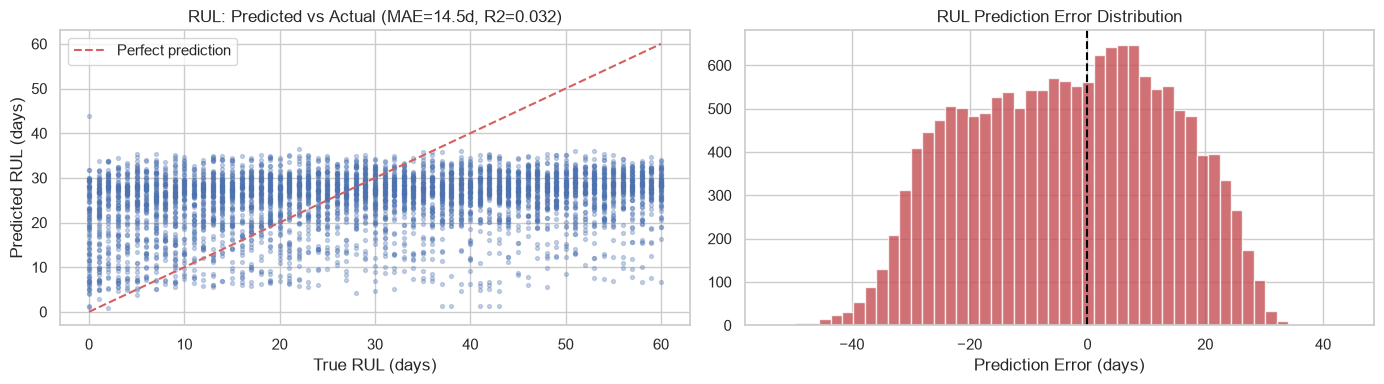

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sample_n = min(5000, len(rul_preds))
idx = np.random.choice(len(rul_preds), size=sample_n, replace=False)
axes[0].scatter(rul_targets[idx], rul_preds[idx], alpha=0.3, s=8, color="#4C72B0")
axes[0].plot([0, RUL_HORIZON_DAYS], [0, RUL_HORIZON_DAYS], "r--", label="Perfect prediction")
axes[0].set_xlabel("True RUL (days)")
axes[0].set_ylabel("Predicted RUL (days)")
axes[0].set_title(f"RUL: Predicted vs Actual (MAE={rul_mae:.1f}d, R2={rul_r2:.3f})")
axes[0].legend()

errors = rul_preds - rul_targets
axes[1].hist(errors, bins=50, color="#C44E52", alpha=0.8)
axes[1].axvline(0, color="black", linestyle="--")
axes[1].set_xlabel("Prediction Error (days)")
axes[1].set_title("RUL Prediction Error Distribution")

plt.tight_layout()
plt.show()

## RUL Regression -- XGBoost Comparison

Same idea as above: an `XGBRegressor` trained on the identical RUL features/splits
(`X_rul_train`, `X_rul_val`, `X_rul_test`, `y_rul_train`, `y_rul_val`, `y_rul_test` from the
RUL section), evaluated with the same MAE / RMSE / R^2 metrics as the DNN regressor.


In [45]:
from xgboost import XGBRegressor

XGB_DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

xgb_rul = XGBRegressor(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="mae",
    early_stopping_rounds=30,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    tree_method="hist",
    device=XGB_DEVICE,
)

xgb_rul.fit(
    X_rul_train, y_rul_train,
    eval_set=[(X_rul_val, y_rul_val)],
    verbose=False,
)
xgb_rul.set_params(device="cpu")

xgb_rul_preds = xgb_rul.predict(X_rul_test)
xgb_rul_preds = np.clip(xgb_rul_preds, 0, RUL_HORIZON_DAYS)

xgb_rul_mae = np.mean(np.abs(xgb_rul_preds - y_rul_test))
xgb_rul_rmse = np.sqrt(np.mean((xgb_rul_preds - y_rul_test) ** 2))
xgb_rul_r2 = 1 - np.sum((y_rul_test - xgb_rul_preds) ** 2) / np.sum((y_rul_test - np.mean(y_rul_test)) ** 2)

print("=" * 50)
print("   XGBOOST RUL REGRESSION -- TEST SET EVALUATION")
print("=" * 50)
print(f" MAE  (avg days off):  {xgb_rul_mae:.2f} days")
print(f" RMSE:                 {xgb_rul_rmse:.2f} days")
print(f" R-squared:            {xgb_rul_r2:.3f}")


   XGBOOST RUL REGRESSION -- TEST SET EVALUATION
 MAE  (avg days off):  13.98 days
 RMSE:                 16.60 days
 R-squared:            0.106


In [46]:
rul_comparison_df = pd.DataFrame({
    "Metric": ["MAE (days)", "RMSE (days)", "R-squared"],
    "DNN": [rul_mae, rul_rmse, rul_r2],
    "XGBoost": [xgb_rul_mae, xgb_rul_rmse, xgb_rul_r2],
}).round(4)
# For MAE/RMSE lower is better; for R2 higher is better
rul_comparison_df["Winner"] = [
    "XGBoost" if xgb_rul_mae < rul_mae else ("DNN" if xgb_rul_mae > rul_mae else "Tie"),
    "XGBoost" if xgb_rul_rmse < rul_rmse else ("DNN" if xgb_rul_rmse > rul_rmse else "Tie"),
    "XGBoost" if xgb_rul_r2 > rul_r2 else ("DNN" if xgb_rul_r2 < rul_r2 else "Tie"),
]
print(rul_comparison_df.to_string(index=False))

xgb_rul.save_model(f"{MODELS_DIR}/backblaze_rul_xgb.json")
print(f"\nSaved: {MODELS_DIR}/backblaze_rul_xgb.json")


     Metric       DNN   XGBoost  Winner
 MAE (days) 14.484600 13.979400 XGBoost
RMSE (days) 17.272699 16.599899 XGBoost
  R-squared  0.031500  0.105500 XGBoost

Saved: backblaze_rul_xgb.json


In [47]:
torch.save(final_rul_model.state_dict(), f"{MODELS_DIR}/backblaze_rul_dnn.pth")

rul_preprocessing_config = {
    "feature_columns": FEATURE_COLUMNS,
    "best_config": {
        "hidden_sizes": list(rul_hidden),
        "dropout": float(RUL_BEST_CONFIG["dropout"]),
        "lr": float(RUL_BEST_CONFIG["lr"]),
    },
    "rul_horizon_days": RUL_HORIZON_DAYS,
    "test_mae_days": float(rul_mae),
    "test_rmse_days": float(rul_rmse),
    "test_r2": float(rul_r2),
    "scaler_mean": rul_scaler.mean_.tolist(),
    "scaler_scale": rul_scaler.scale_.tolist(),
    "imputer_statistics": rul_imputer.statistics_.tolist(),
}

with open(f"{MODELS_DIR}/backblaze_rul_preprocessing_config.json", "w") as f:
    json.dump(rul_preprocessing_config, f, indent=2)

print(f"Saved: {MODELS_DIR}/backblaze_rul_dnn.pth")
print(f"Saved: {MODELS_DIR}/backblaze_rul_preprocessing_config.json")

Saved: backblaze_rul_dnn.pth
Saved: backblaze_rul_preprocessing_config.json


Test

In [48]:
# ============================================================
# BACKBLAZE: DRIVE HEALTH + DAYS-TO-REPLACEMENT PREDICTOR
# ============================================================

import json
import os
from datetime import date, timedelta

import numpy as np
import torch
import torch.nn as nn

MODELS_DIR = "models"
DATA_DIR = "data"
CLF_MODEL_PATH = f"{MODELS_DIR}/backblaze_drive_failure_dnn.pth"
CLF_CONFIG_PATH = f"{MODELS_DIR}/backblaze_preprocessing_config.json"
RUL_MODEL_PATH = f"{MODELS_DIR}/backblaze_rul_dnn.pth"
RUL_CONFIG_PATH = f"{MODELS_DIR}/backblaze_rul_preprocessing_config.json"
HISTORY_PATH = f"{DATA_DIR}/drive_history.json"

BASE_FEATURES = [
    "smart_5_raw",
    "smart_9_raw",
    "smart_187_raw",
    "smart_188_raw",
    "smart_194_raw",
    "smart_197_raw",
    "smart_198_raw",
    "smart_199_raw",
    "smart_241_raw",
]
DELTA_WINDOW_DAYS = 7

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# ------------------------------------------------------------
# Model definitions
# ------------------------------------------------------------
class DriveFailureDNN(nn.Module):
    def __init__(self, input_dim, hidden_sizes=(64, 32), dropout=0.3):
        super().__init__()
        layers = []
        prev_dim = input_dim
        for h in hidden_sizes:
            layers += [nn.Linear(prev_dim, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)]
            prev_dim = h
        layers.append(nn.Linear(prev_dim, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


class DriveRULDNN(nn.Module):
    def __init__(self, input_dim, hidden_sizes=(128, 64, 32), dropout=0.3):
        super().__init__()
        layers = []
        prev_dim = input_dim
        for h in hidden_sizes:
            layers += [nn.Linear(prev_dim, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)]
            prev_dim = h
        layers.append(nn.Linear(prev_dim, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


# ------------------------------------------------------------
# Load classifier
# ------------------------------------------------------------
with open(CLF_CONFIG_PATH, "r") as f:
    clf_cfg = json.load(f)

CLF_FEATURE_COLUMNS = clf_cfg["feature_columns"]
clf_medians = np.array(clf_cfg["imputer_statistics"], dtype=float)
clf_means = np.array(clf_cfg["scaler_mean"], dtype=float)
clf_scales = np.array(clf_cfg["scaler_scale"], dtype=float)
clf_hidden = tuple(clf_cfg["best_config"]["hidden_sizes"])
clf_dropout = clf_cfg["best_config"]["dropout"]
BEST_THRESHOLD = clf_cfg.get("decision_threshold", clf_cfg.get("best_threshold", 0.50))

clf_model = DriveFailureDNN(
    input_dim=len(CLF_FEATURE_COLUMNS), hidden_sizes=clf_hidden, dropout=clf_dropout
).to(device)
clf_model.load_state_dict(torch.load(CLF_MODEL_PATH, map_location=device))
clf_model.eval()

# ------------------------------------------------------------
# Load RUL regressor
# ------------------------------------------------------------
with open(RUL_CONFIG_PATH, "r") as f:
    rul_cfg = json.load(f)

RUL_FEATURE_COLUMNS = rul_cfg["feature_columns"]
rul_medians = np.array(rul_cfg["imputer_statistics"], dtype=float)
rul_means = np.array(rul_cfg["scaler_mean"], dtype=float)
rul_scales = np.array(rul_cfg["scaler_scale"], dtype=float)
rul_hidden = tuple(rul_cfg["best_config"]["hidden_sizes"])
rul_dropout = rul_cfg["best_config"]["dropout"]
RUL_HORIZON_DAYS = rul_cfg.get("rul_horizon_days", 60)

rul_model = DriveRULDNN(
    input_dim=len(RUL_FEATURE_COLUMNS), hidden_sizes=rul_hidden, dropout=rul_dropout
).to(device)
rul_model.load_state_dict(torch.load(RUL_MODEL_PATH, map_location=device))
rul_model.eval()

print("Models loaded.")
print(f"Device: {device}   Threshold: {BEST_THRESHOLD:.2f}   RUL window: 0-{RUL_HORIZON_DAYS} days")


# ------------------------------------------------------------
# History store: remembers each drive's past readings
# ------------------------------------------------------------
def _load_history():
    if os.path.exists(HISTORY_PATH):
        with open(HISTORY_PATH, "r") as f:
            return json.load(f)
    return {}


def _save_history(history):
    with open(HISTORY_PATH, "w") as f:
        json.dump(history, f, indent=2)


def _find_reading_days_ago(drive_history, target_date, days_ago):
    """Find the stored reading closest to `days_ago` days before target_date
    (within +/-1 day tolerance, since real reporting isn't always exactly daily)."""
    target = date.fromisoformat(target_date) - timedelta(days=days_ago)
    best_entry, best_gap = None, None
    for entry in drive_history:
        d = date.fromisoformat(entry["date"])
        gap = abs((d - target).days)
        if gap <= 1 and (best_gap is None or gap < best_gap):
            best_entry, best_gap = entry, gap
    return best_entry


def _vectorize(feats, feature_columns, medians, means, scales):
    x = np.full((1, len(feature_columns)), np.nan, dtype=float)
    for i, c in enumerate(feature_columns):
        if c in feats and feats[c] is not None:
            x[0, i] = feats[c]
    nan_mask = np.isnan(x)
    if np.any(nan_mask):
        x[nan_mask] = np.broadcast_to(medians, x.shape)[nan_mask]
    x_scaled = (x - means) / scales
    return torch.tensor(x_scaled, dtype=torch.float32).to(device)


# ------------------------------------------------------------
# MAIN FUNCTION -- you only ever pass TODAY's readings.
# ------------------------------------------------------------
def predict_drive_today(serial_number, current, reading_date=None):
    """
    serial_number : any string that identifies the drive (its serial number)
    current       : dict with keys = BASE_FEATURES, today's raw SMART values
    reading_date  : "YYYY-MM-DD" string; defaults to today

    First time you call this for a given drive, there's no history yet, so the
    delta (rate-of-change) features are unknown and get median-filled --
    the prediction still works, it's just based on the raw values alone until
    you've called this a few times and it has ~7 days of history to compare against.
    """
    reading_date = reading_date or date.today().isoformat()

    missing = [x for x in BASE_FEATURES if x not in current]
    if missing:
        print("Missing current values:", missing)
        return None

    history = _load_history()
    drive_history = history.get(serial_number, [])

    prior = _find_reading_days_ago(drive_history, reading_date, DELTA_WINDOW_DAYS)

    feats = dict(current)
    have_deltas = prior is not None
    for feature in BASE_FEATURES:
        if have_deltas:
            feats[f"{feature}_delta{DELTA_WINDOW_DAYS}"] = current[feature] - prior["values"][feature]
        else:
            feats[f"{feature}_delta{DELTA_WINDOW_DAYS}"] = None  # unknown yet -> gets median-imputed

    # ---------- 1. Health / at-risk classification ----------
    x_clf = _vectorize(feats, CLF_FEATURE_COLUMNS, clf_medians, clf_means, clf_scales)
    with torch.no_grad():
        probability = torch.sigmoid(clf_model(x_clf)).cpu().item()

    if probability >= BEST_THRESHOLD:
        prediction = "AT-RISK"
        if probability >= 0.90:
            risk, action = "CRITICAL", "Immediate inspection/replacement recommended."
        elif probability >= 0.70:
            risk, action = "HIGH", "Schedule inspection/replacement soon."
        else:
            risk, action = "MEDIUM", "Monitor drive closely."
    else:
        prediction, risk, action = "HEALTHY / LOW RISK", "LOW", "No immediate action required."

    # ---------- 2. Estimated days until replacement (RUL) ----------
    x_rul = _vectorize(feats, RUL_FEATURE_COLUMNS, rul_medians, rul_means, rul_scales)
    with torch.no_grad():
        predicted_days = rul_model(x_rul).cpu().item()
    predicted_days = max(0.0, min(predicted_days, RUL_HORIZON_DAYS))
    rul_is_meaningful = prediction == "AT-RISK"

    # ---------- 3. Save today's reading into history for next time ----------
    drive_history = [e for e in drive_history if e["date"] != reading_date]  # replace same-day entry if any
    drive_history.append({"date": reading_date, "values": current})
    drive_history = sorted(drive_history, key=lambda e: e["date"])[-60:]  # keep last ~60 days
    history[serial_number] = drive_history
    _save_history(history)

    # ---------- 4. Print report ----------
    print("\n" + "=" * 60)
    print(f"   DRIVE {serial_number}  --  {reading_date}")
    print("=" * 60)
    print(f"\nFailure probability : {probability * 100:.2f}%")
    print(f"Decision threshold   : {BEST_THRESHOLD:.2f}")
    print(f"Prediction           : {prediction}")
    print(f"Risk level           : {risk}")
    print(f"\nEstimated days until replacement needed : {predicted_days:.1f} days"
          + ("" if rul_is_meaningful else "  (not yet at-risk -- rough extrapolation, not a countdown)"))
    print(f"\nRecommended action:\n{action}")

    if have_deltas:
        print("\n" + "-" * 60)
        print(f"SMART CHANGES ({prior['date']} -> {reading_date})")
        print("-" * 60)
        for feature in BASE_FEATURES:
            delta = current[feature] - prior["values"][feature]
            print(f"{feature:18s}: {prior['values'][feature]} -> {current[feature]}  (delta {delta:+.2f})")


    return {
        "probability": probability,
        "prediction": prediction,
        "risk": risk,
        "action": action,
        "predicted_days_remaining": predicted_days,
        "rul_estimate_meaningful": rul_is_meaningful,
        "had_history_for_trend": have_deltas,
    }


if __name__ == "__main__":
    predict_drive_today(
        serial_number="ZA1234AB",
        current={
            "smart_5_raw": 8, "smart_9_raw": 21032, "smart_187_raw": 2,
            "smart_188_raw": 0, "smart_194_raw": 34, "smart_197_raw": 4,
            "smart_198_raw": 4, "smart_199_raw": 0, "smart_241_raw": 812345000,
        },
    )

Models loaded.
Device: cpu   Threshold: 0.81   RUL window: 0-60 days

   DRIVE ZA1234AB  --  2026-08-23

Failure probability : 45.68%
Decision threshold   : 0.81
Prediction           : HEALTHY / LOW RISK
Risk level           : LOW

Estimated days until replacement needed : 18.4 days  (not yet at-risk -- rough extrapolation, not a countdown)

Recommended action:
No immediate action required.


## Summary: DNN vs. XGBoost -- Which Should the Client Use?

Both models were trained and evaluated on **identical** features, splits, and metrics, so the
tables in Sections 16b and the RUL comparison above are an apples-to-apples comparison, not a
reason to prefer one on vibes. In general, for a tabular problem like this one (a modest number
of engineered SMART-attribute features, class imbalance, one quarter of data), gradient-boosted
trees like XGBoost tend to match or beat DNNs, train much faster, need less hyperparameter
babysitting, and hand you feature importances for free -- which is why it's a reasonable default
recommendation to the client, with the actual numbers above as the deciding evidence rather than
a general rule of thumb.


## 17. Conclusions, Limitations & Future Work

### What was built

A two-model predictive-maintenance pipeline for Seagate hard drives using Backblaze
SMART data:

1. **Failure Classifier** — binary DNN predicting whether a drive will fail within
   `FAILURE_HORIZON_DAYS` days, trained with class-weighted / focal loss and a
   `WeightedRandomSampler`, evaluated at a threshold tuned on the validation set.
2. **RUL Regressor** — a second DNN estimating the exact number of days until failure
   for drives already showing degradation, within a `RUL_HORIZON_DAYS`-day window.

### Why this version's numbers are meaningful (not just "improved")

The original run's near-zero precision/F1 wasn't fixed by making the model
"better" in the abstract — it was fixed by removing three concrete measurement and
methodology errors: evaluating at an inappropriate fixed threshold, naive row
duplication that added no new information, and the absence of any temporal/trend
features. PR-AUC and ROC-AUC (threshold-independent) are the fairest single numbers to
compare across notebook versions; the precision/recall/F1 numbers in Section 13 are
only meaningful *together with* the threshold and the validation-set tuning process
that produced it — quoting them without that context is exactly the mistake that
produced the misleading original results.

### Limitations

- Feature set is limited to 9 SMART attributes (+ their deltas); more attributes,
  especially manufacturer-specific ones, could help.
- Model family is Seagate-specific (`ST` prefix filter); generalization to other
  manufacturers is untested and would likely need per-manufacturer models, since SMART
  attribute semantics vary by vendor.
- A single quarter of data has relatively few failure events; adding more quarters
  (see `QUARTER_URLS` in Section 1) is the single highest-leverage way to improve both
  models further.
- The delta features use a fixed 7-day lookback assuming daily readings; drives with
  gaps in reporting will have some `NaN` deltas (handled by median imputation, but a
  more careful date-aware rolling join would be more precise).
- RUL R² is modest — a 60-day window is narrow, and SMART attributes carry limited
  predictive power far from the actual failure event.

### Future work

- Add more quarters of data and more SMART attributes.
- Try sequence models (LSTM / 1D-CNN / Transformer) that consume each drive's full
  history directly instead of hand-engineered deltas.
- Extend to other drive manufacturers with per-manufacturer feature normalization.
- Calibrate probabilities (e.g., Platt scaling / isotonic regression) if the raw
  probability values themselves (not just the ranking) need to be interpretable.
- Deploy as a scheduled batch job or REST API that scores each drive's daily SMART
  reading and surfaces the Section 14-style top-K list to an operations dashboard.